# Ridge

## Импорт библиотек, загрузка датасетов

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,  mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Загрузка данных
train = pd.read_csv('data/train_preprocessed.csv')
test = pd.read_csv('data/test_preprocessed.csv')

## Построение модели

In [29]:
X = train.drop('price_per_sqm', axis=1)
y = np.log1p(train['price_per_sqm'])

X_sub = test.drop('id', axis=1)
test_ids = test['id']

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y, test_size=0.2, random_state=42)


### Стандартизация признаков

In [30]:
numeric_cols = ['area', 'year', 'floor', 'total_floors']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_sub[numeric_cols] = scaler.transform(X_sub[numeric_cols])

### Регулиризация

In [31]:
alphas = np.logspace(-2, 3, 20)
alphas

array([1.00000000e-02, 1.83298071e-02, 3.35981829e-02, 6.15848211e-02,
       1.12883789e-01, 2.06913808e-01, 3.79269019e-01, 6.95192796e-01,
       1.27427499e+00, 2.33572147e+00, 4.28133240e+00, 7.84759970e+00,
       1.43844989e+01, 2.63665090e+01, 4.83293024e+01, 8.85866790e+01,
       1.62377674e+02, 2.97635144e+02, 5.45559478e+02, 1.00000000e+03])

In [32]:
model = Ridge()
param_dict = {'alpha': alphas}
searcher = GridSearchCV(
    model,
    param_dict,
    cv=5,
    scoring='neg_mean_squared_error'
    )
searcher.fit(X_train, y_train_log)
best_alpha = searcher.best_params_['alpha']
print(f'Лучшее значение alpha: {best_alpha}')

Лучшее значение alpha: 0.20691380811147891


Text(0, 0.5, 'CV score')

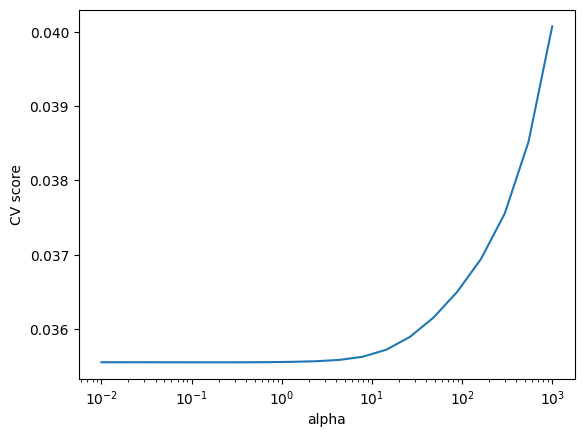

In [33]:
plt.plot(alphas, -searcher.cv_results_["mean_test_score"])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV score")

In [34]:
model = Ridge(best_alpha)
model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)
model.coef_, model.intercept_

(array([ 1.11777573e-01,  1.94694882e-01,  8.01368879e-02,  1.12475558e-01,
         1.39011090e-01,  1.26229254e-01,  1.11653483e-01,  2.19943025e-01,
         1.47802574e-01,  9.38369582e-02, -6.88179557e-02,  2.81799443e-02,
         2.03459596e-02,  3.51328307e-02, -2.83080956e-02,  6.25380135e-04,
        -3.81151582e-01, -2.76291084e-02, -2.48877345e-02, -3.25988063e-01,
        -7.58162815e-02, -7.82155885e-02, -4.00135605e-01,  1.67037020e-04,
         7.82501373e-03,  1.79157956e-02, -4.72633278e-02, -1.39577335e-02,
         1.73313735e-02, -3.37364003e-03, -2.37095480e-02,  4.77118097e-02,
        -1.74115424e-02,  2.35019790e-02,  7.67849094e-03]),
 np.float64(7.204550760609674))

In [35]:
def show_weights(features, weights, means, scales):
    fig, axs = plt.subplots(figsize=(12, 10), ncols=3)
    sorted_weights = sorted(zip(weights, features, means, scales), reverse=True)
    weights, features, means, scales = zip(*sorted_weights)
    features = list(features)

    sns.barplot(y=features, x=list(weights), ax=axs[0], color='black')
    axs[0].set_xlabel("Weight")
    sns.barplot(y=features, x=list(means), ax=axs[1], color='black')
    axs[1].set_xlabel("Mean")
    sns.barplot(y=features, x=list(scales), ax=axs[2], color='black')
    axs[2].set_xlabel("Scale")
    plt.tight_layout()

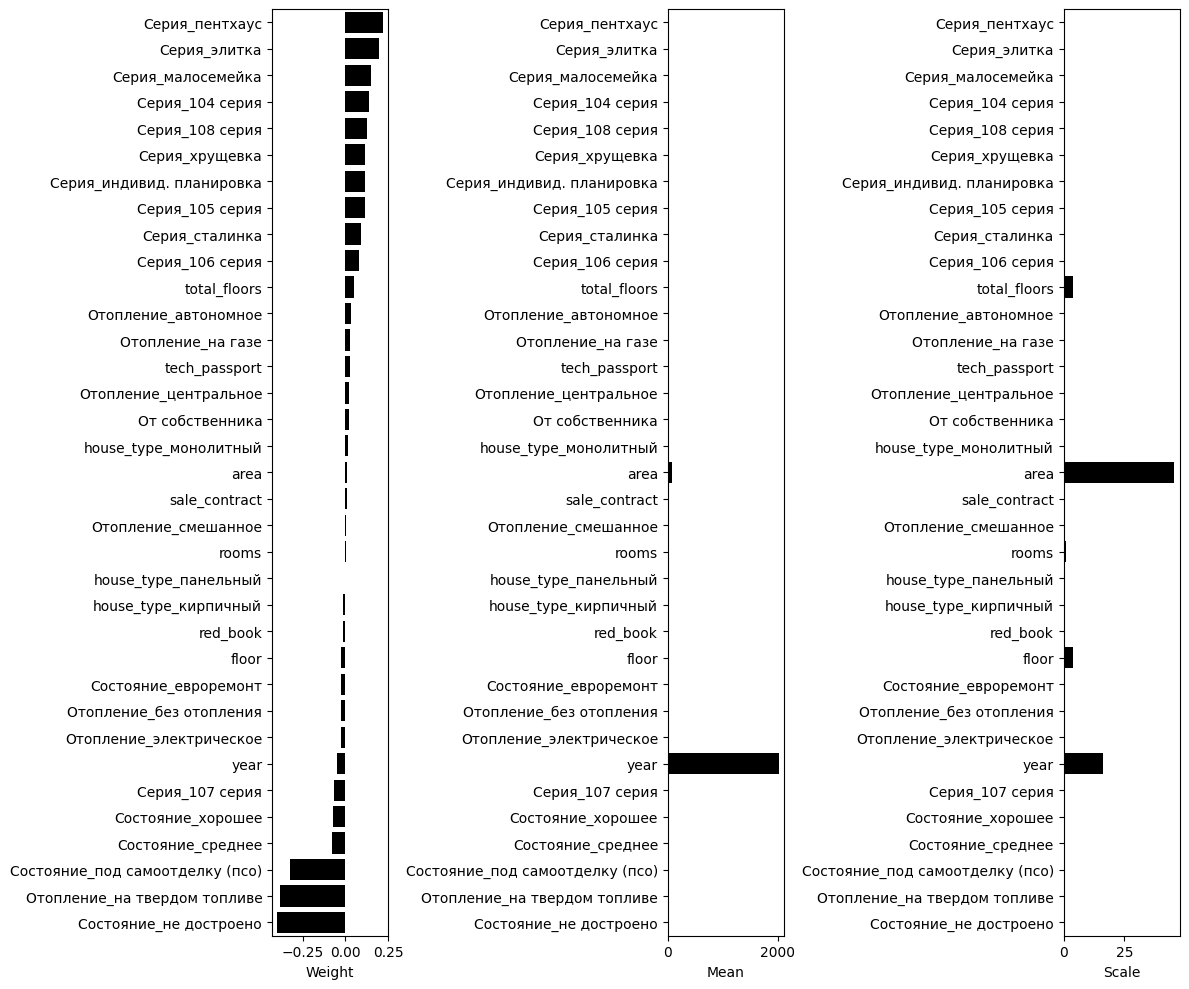

In [36]:
show_weights(X, model.coef_, X.mean(), X.std())

In [37]:
print("R2:\t %.4f" % r2_score(y_test, y_pred))
print("MAPE:\t %.4f" % mean_absolute_percentage_error(y_test, y_pred))
print('-----------------')
print("MSE:\t %.4f" % mean_squared_error(y_test, y_pred))
print("RMSE:\t %.4f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:\t %.4f" % mean_absolute_error(y_test, y_pred))

R2:	 0.0055
MAPE:	 0.1450
-----------------
MSE:	 7292990.6448
RMSE:	 2700.5538
MAE:	 279.9886


In [38]:
cv_scores = cross_val_score(model, X_train, np.expm1(y_train_log), cv=5, scoring='neg_mean_absolute_percentage_error')
print("Cross validation scores:\n\t", "\n\t".join("%.4f" % x for x in cv_scores))
print("Mean CV MAPE = %.4f" % np.mean(-cv_scores))

Cross validation scores:
	 -0.1469
	-0.1536
	-0.1472
	-0.1478
	-0.1482
Mean CV MAPE = 0.1487


## Проверка модели на submission.csv

In [39]:
y_sub_pred_log = model.predict(X_sub)
y_sub_pred = np.expm1(y_sub_pred_log)
y_sub = y_sub_pred * test['area']
submission_data = pd.DataFrame({'id': test_ids, 'usd_price': y_sub})
submission_data.to_csv('data\Ridge.csv', index=False)

In [40]:
y_sub.max(), y_sub.min()

(np.float64(1018527.9000775325), np.float64(16194.753094879763))